# House Price Prediction (Regression)



## 1. Import Required Libraries

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True


## 2. Load the Dataset

In [ ]:
BASE_DIR = Path.cwd()
DATA_PATH = BASE_DIR / 'house_price_regression_dataset.csv'
df = pd.read_csv(DATA_PATH)
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


## 3. Check Dataset

In [ ]:
print('Shape:', df.shape)
print()
print('Data types:')
print(df.dtypes)
print()
print('Summary statistics:')
df.describe().T

Shape: (1000, 8)

Data types:
Square_Footage            int64
Num_Bedrooms              int64
Num_Bathrooms             int64
Year_Built                int64
Lot_Size                float64
Garage_Size               int64
Neighborhood_Quality      int64
House_Price             float64
dtype: object

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
Square_Footage,1000.0,2815.422000,1255.514921,503.000000,1749.500000,2862.500000,3849.500000,4.999000e+03
Num_Bedrooms,1000.0,2.990000,1.427564,1.000000,2.000000,3.000000,4.000000,5.000000e+00
Num_Bathrooms,1000.0,1.973000,0.820332,1.000000,1.000000,2.000000,3.000000,3.000000e+00
Year_Built,1000.0,1986.550000,20.632916,1950.000000,1969.000000,1986.000000,2004.250000,2.022000e+03
Lot_Size,1000.0,2.778087,1.297903,0.506058,1.665946,2.809740,3.923317,4.989303e+00
Garage_Size,1000.0,1.022000,0.814973,0.000000,0.000000,1.000000,2.000000,2.000000e+00
Neighborhood_Quality,1000.0,5.615000,2.887059,1.000000,3.000000,6.000000,8.000000,1.000000e+01
House_Price,1000.0,618861.018647,253568.058375,111626.853424,401648.228909,628267.291129,827141.277637,1.108237e+06


## 4. Handle Missing Values

In [ ]:
missing_values = df.isna().sum()
missing_values

,0
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


**Observation:** No missing values are present, so no imputation is required.

## 5. Remove Duplicate Records

In [ ]:
duplicate_rows = df.duplicated().sum()
print('Duplicate rows:', duplicate_rows)
if duplicate_rows > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print('Duplicates removed. New shape:', df.shape)
else:
    print('No duplicates found, so the dataset is unchanged.')

Duplicate rows: 0
No duplicates found, so the dataset is unchanged.


## 6. Perform Univariate Analysis

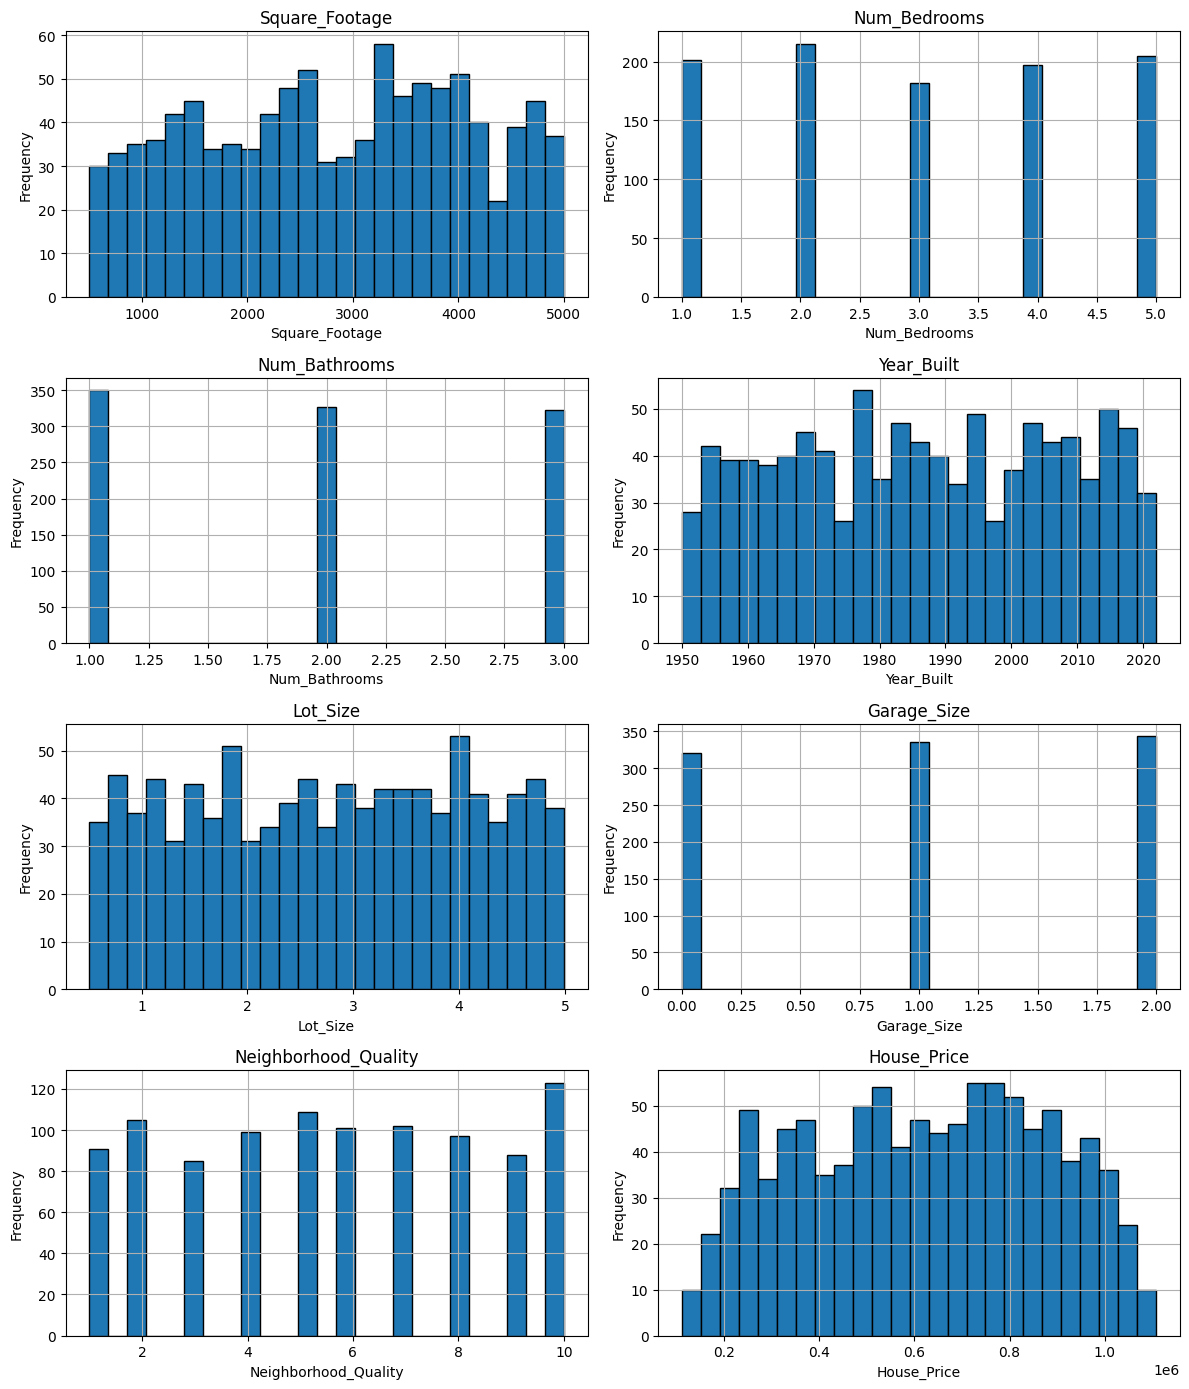

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.ravel()
for ax, column in zip(axes, df.columns):
    ax.hist(df[column], bins=25, edgecolor='black')
    ax.set_title(column)
    ax.set_xlabel(column)
    ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()

## 7. Perform Bivariate Analysis

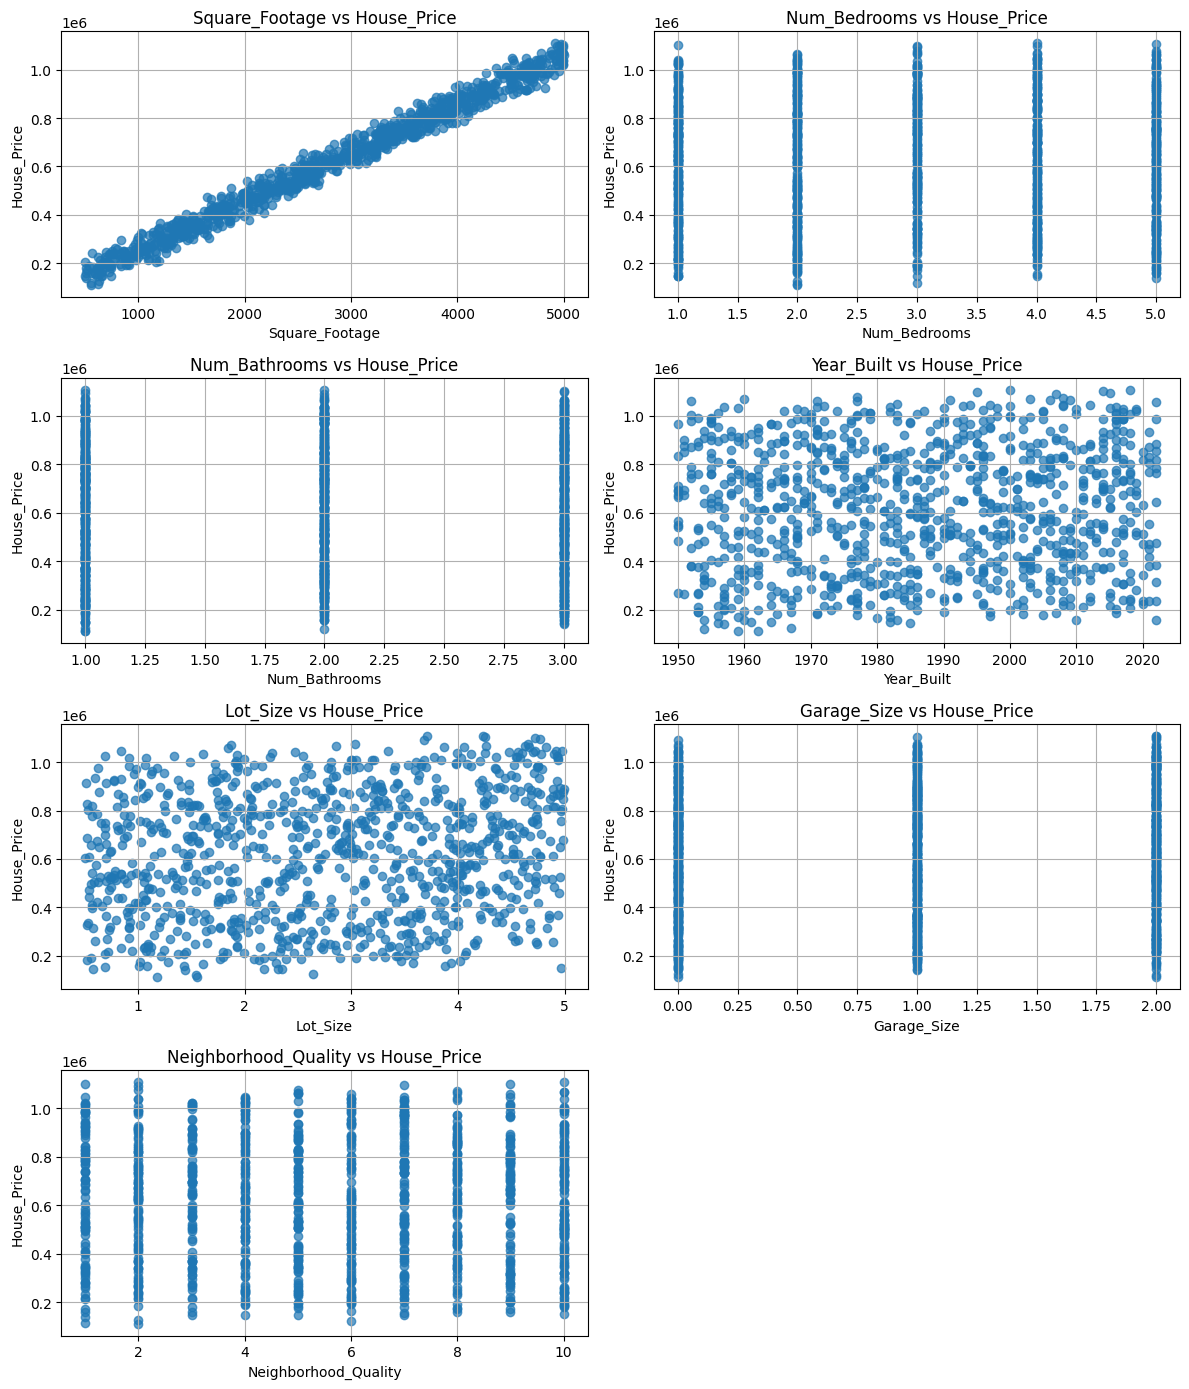

In [ ]:
feature_cols = [col for col in df.columns if col != 'House_Price']
fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.ravel()
for i, column in enumerate(feature_cols):
    axes[i].scatter(df[column], df['House_Price'], alpha=0.7)
    axes[i].set_title(f'{column} vs House_Price')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('House_Price')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

## 8. Generate Correlation Heatmap

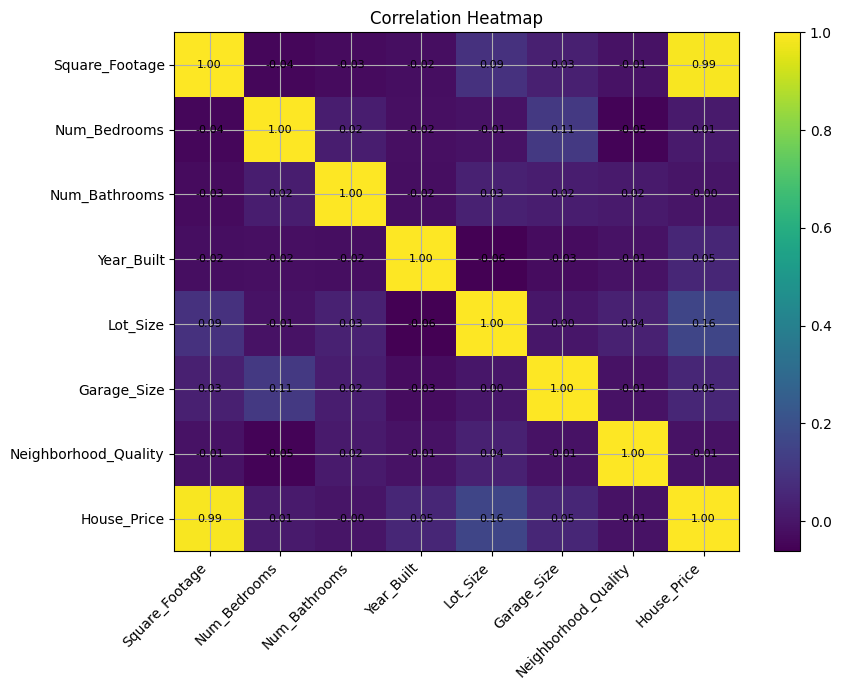

,House_Price
House_Price,1.000000
Square_Footage,0.991261
Lot_Size,0.160412
Garage_Size,0.052133
Year_Built,0.051967
Num_Bedrooms,0.014633
Num_Bathrooms,-0.001862
Neighborhood_Quality,-0.007770


In [ ]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, aspect='auto')
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

corr['House_Price'].sort_values(ascending=False)

## 9. Detect and Handle Outliers

In [ ]:
outlier_counts = {}
for col in df.columns:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier_counts[col] = int(((df[col] < lower) | (df[col] > upper)).sum())

pd.Series(outlier_counts, name='IQR_Outlier_Count')

,IQR_Outlier_Count
Square_Footage,0
Num_Bedrooms,0
Num_Bathrooms,0
Year_Built,0
Lot_Size,0
Garage_Size,0
Neighborhood_Quality,0
House_Price,0


**Observation:** No IQR-based outliers were detected, so no rows were removed or capped.

## 10. Apply Encoding (if categorical variables exist)

In [ ]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns:', categorical_columns)
print('Encoding required:', 'Yes' if categorical_columns else 'No')

Categorical columns: []
Encoding required: No


**Observation:** All variables are numeric, so encoding is not required for this dataset.

## 11. Apply Log Transformation

In [ ]:
skewness = df.skew(numeric_only=True).sort_values(key=lambda s: s.abs(), ascending=False)
skewness

,0
Square_Footage,-0.066001
House_Price,-0.063955
Num_Bathrooms,0.049917
Lot_Size,-0.044288
Garage_Size,-0.040400
Num_Bedrooms,0.025884
Year_Built,-0.021254
Neighborhood_Quality,-0.020445


The skewness values are already very small, so strong log transformation is not necessary. To still satisfy the task requirement, an optional **log-transformed target model** is tested later and compared with the baseline models.

## 12. Separate Features and Target Variable

In [ ]:
X = df.drop(columns=['House_Price'])
y = df['House_Price']
print('Feature shape:', X.shape)
print('Target shape:', y.shape)

Feature shape: (1000, 7)
Target shape: (1000,)


## 13. Perform Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

X_train: (800, 7)
X_test : (200, 7)
y_train: (800,)
y_test : (200,)


## 14. Apply Feature Scaling

In [ ]:
# Scaling is applied inside the model pipelines so that the exact same transformation
# learned from the training data is also applied to the test data.
from sklearn.pipeline import Pipeline
print('Feature scaling will be applied using StandardScaler inside each pipeline.')

Feature scaling will be applied using StandardScaler inside each pipeline.


## 15. Train Regression Models

In [ ]:
linear_regression = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

knn_regression = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsRegressor(n_neighbors=7, weights='distance', p=2))
])

log_linear_regression = Pipeline([
    ('scaler', StandardScaler()),
    ('model', TransformedTargetRegressor(
        regressor=LinearRegression(),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

linear_regression.fit(X_train, y_train)
knn_regression.fit(X_train, y_train)
log_linear_regression.fit(X_train, y_train)

linear_pred = linear_regression.predict(X_test)
knn_pred = knn_regression.predict(X_test)
log_pred = log_linear_regression.predict(X_test)
print('Models trained successfully.')

Models trained successfully.


## 16. Evaluate Models Using MAE, MSE, RMSE, MAPE, R², and Adjusted R²

In [ ]:
def evaluate_regression(y_true, y_pred, n_features):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    r2 = r2_score(y_true, y_pred)
    n = len(y_true)
    adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - n_features - 1)
    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'MAPE': mape,
        'R2': r2,
        'Adjusted_R2': adjusted_r2,
    }

results = pd.DataFrame([
    {'Model': 'Linear Regression', **evaluate_regression(y_test, linear_pred, X.shape[1])},
    {'Model': 'KNN Regression (k=7, distance)', **evaluate_regression(y_test, knn_pred, X.shape[1])},
    {'Model': 'Linear Regression with Log Target', **evaluate_regression(y_test, log_pred, X.shape[1])},
]).sort_values('R2', ascending=False)

results

,Model,MAE,MSE,RMSE,MAPE,R2,Adjusted_R2
0,Linear Regression,8174.583600,1.014348e+08,10071.484424,1.663906,0.998426,0.998369
2,Linear Regression with Log Target,51521.693742,4.485156e+09,66971.309894,9.332199,0.930418,0.927881
1,"KNN Regression (k=7, distance)",64689.855815,6.437487e+09,80233.951176,14.751993,0.900130,0.896489


## Cross-Validation Check

In [ ]:
linear_cv_rmse = -cross_val_score(
    linear_regression, X_train, y_train, cv=5,
    scoring='neg_root_mean_squared_error'
).mean()
knn_cv_rmse = -cross_val_score(
    knn_regression, X_train, y_train, cv=5,
    scoring='neg_root_mean_squared_error'
).mean()

pd.DataFrame({
    'Model': ['Linear Regression', 'KNN Regression (k=7, distance)'],
    'CV_RMSE': [linear_cv_rmse, knn_cv_rmse]
})

,Model,CV_RMSE
0,Linear Regression,9747.432899
1,"KNN Regression (k=7, distance)",80932.710886


## Actual vs Predicted Plots

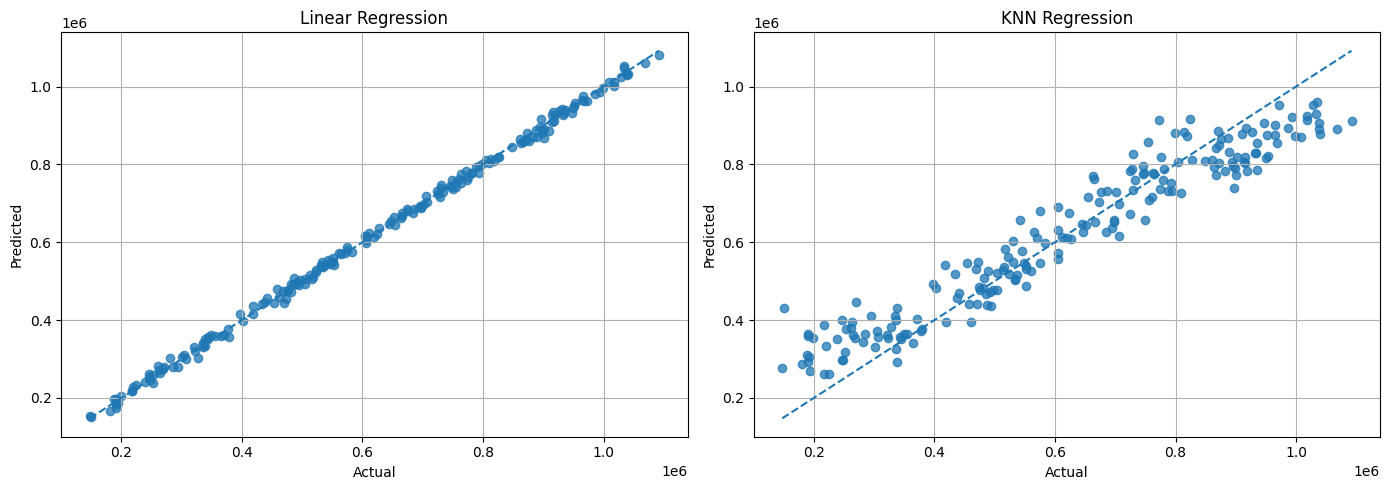

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, linear_pred, alpha=0.75)
low = min(y_test.min(), linear_pred.min())
high = max(y_test.max(), linear_pred.max())
axes[0].plot([low, high], [low, high], linestyle='--')
axes[0].set_title('Linear Regression')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')

axes[1].scatter(y_test, knn_pred, alpha=0.75)
low = min(y_test.min(), knn_pred.min())
high = max(y_test.max(), knn_pred.max())
axes[1].plot([low, high], [low, high], linestyle='--')
axes[1].set_title('KNN Regression')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')

plt.tight_layout()
plt.show()

## Linear Regression Coefficients

In [ ]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Standardized_Coefficient': linear_regression.named_steps['model'].coef_
}).sort_values('Standardized_Coefficient', key=lambda s: s.abs(), ascending=False)
coef_df

,Feature,Standardized_Coefficient
0,Square_Footage,249787.914843
3,Year_Built,20662.121612
4,Lot_Size,19088.111033
1,Num_Bedrooms,14524.734398
2,Num_Bathrooms,6695.906775
5,Garage_Size,4219.449419
6,Neighborhood_Quality,335.247488


## Final Conclusion

- The dataset is already clean: no missing values, no duplicate rows, no categorical columns, and no IQR-detected outliers.
- `Square_Footage` has an extremely strong positive relationship with `House_Price`, which explains why the linear model performs exceptionally well.
- **Linear Regression is the best model** on this dataset, clearly outperforming KNN regression and the optional log-transformed target model.

## GitHub Link Placeholder

`https://github.com/anshul55555/house-price-regression`